In [ ]:
!pip install spikingjelly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 437.6/437.6 kB 11.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Cài đặt thư viện

In [ ]:
import os
import torch
import torch.nn as nn
import math
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import torchvision
from torchvision.ops import MLP
import torchvision.transforms as transforms

import spikingjelly
from spikingjelly.activation_based import layer, functional
from spikingjelly.activation_based import surrogate, neuron
from torch.nn.common_types import _size_2_t

from spikingjelly.activation_based.neuron import LIFNode
from spikingjelly.activation_based.layer import SeqToANNContainer


from typing import Any, List, Mapping
from timm.models import register_model
from collections import Counter
from torch.utils.data import WeightedRandomSampler
from tqdm import tqdm

# Triển khai các class submodules hỗ trợ model chính

In [ ]:
class IF(neuron.IFNode):
    def __init__(self):
        super().__init__(v_threshold=1., v_reset=0., surrogate_function=surrogate.ATan(),
                         detach_reset=True, step_mode='m', backend='torch', store_v_seq=False)


class LIF(neuron.LIFNode):
    def __init__(self):
        super().__init__(tau=2., decay_input=True, v_threshold=1., v_reset=0.,
                         surrogate_function=surrogate.ATan(), detach_reset=True, step_mode='m',
                         backend='torch', store_v_seq=False)


class PLIF(neuron.ParametricLIFNode):
    def __init__(self):
        super().__init__(init_tau=2., decay_input=True, v_threshold=1., v_reset=0.,
                         surrogate_function=surrogate.ATan(), detach_reset=True, step_mode='m',
                         backend='torch', store_v_seq=False)


class BN(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.bn = nn.BatchNorm2d(num_features, eps=1e-5, momentum=0.1, affine=True,
                                 track_running_stats=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() != 5:
            raise ValueError(
                f'expected x with shape [T, N, C, H, W], but got x with shape {x.shape}!')
        return functional.seq_to_ann_forward(x, self.bn)


class SpikingMatmul(nn.Module):
    def __init__(self, spike: str) -> None:
        super().__init__()
        assert spike == 'l' or spike == 'r' or spike == 'both'
        self.spike = spike

    def forward(self, left: torch.Tensor, right: torch.Tensor):
        return torch.matmul(left, right)


class Conv3x3(layer.Conv2d):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: _size_2_t = 1,
        dilation: _size_2_t = 1,
        groups: int = 1,
        bias: bool = False,
    ) -> None:
        super().__init__(in_channels, out_channels, kernel_size=3, stride=stride, padding=dilation,
                         dilation=dilation, groups=groups, bias=bias, padding_mode='zeros',
                         step_mode='m')


class Conv1x1(layer.Conv2d):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        stride: _size_2_t = 1,
        bias: bool = False,
    ) -> None:
        super().__init__(in_channels, out_channels, kernel_size=1, stride=stride, padding=0,
                         dilation=1, groups=1, bias=bias, padding_mode='zeros', step_mode='m')


class Linear(layer.Linear):
    def __init__(
        self,
        in_features: int,
        out_features: int,
        bias: bool = False,
    ) -> None:
        super().__init__(in_features, out_features, bias=bias, step_mode='m')

# Xây dựng model Spike-Resformer

In [ ]:
class GWFFN(nn.Module):
    def __init__(self, in_channels, num_conv=1, ratio=4, group_size=64, activation=LIF):
        super().__init__()
        inner_channels = in_channels * ratio
        self.up = nn.Sequential(
            activation(),
            Conv1x1(in_channels, inner_channels),
            BN(inner_channels),
        )
        self.conv = nn.ModuleList()
        for _ in range(num_conv):
            self.conv.append(
                nn.Sequential(
                    activation(),
                    Conv3x3(inner_channels, inner_channels, groups=inner_channels // group_size),
                    BN(inner_channels),
                ))
        self.down = nn.Sequential(
            activation(),
            Conv1x1(inner_channels, in_channels),
            BN(in_channels),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_feat_out = x.clone()
        x = self.up(x)
        x_feat_in = x.clone()
        for m in self.conv:
            x = m(x)
        x = x + x_feat_in
        x = self.down(x)
        x = x + x_feat_out
        return x


class DSSA(nn.Module):
    def __init__(self, dim, num_heads, lenth, patch_size, activation=LIF):
        super().__init__()
        assert dim % num_heads == 0, f"dim {dim} should be divided by num_heads {num_heads}."
        self.dim = dim
        self.num_heads = num_heads
        self.lenth = lenth
        self.register_buffer('firing_rate_x', torch.zeros(1, 1, num_heads, 1, 1))
        self.register_buffer('firing_rate_attn', torch.zeros(1, 1, num_heads, 1, 1))
        self.init_firing_rate_x = False
        self.init_firing_rate_attn = False
        self.momentum = 0.999

        self.activation_in = activation()

        self.W = layer.Conv2d(dim, dim * 2, patch_size, patch_size, bias=False, step_mode='m')
        self.norm = BN(dim * 2)
        self.matmul1 = SpikingMatmul('r')
        self.matmul2 = SpikingMatmul('r')
        self.activation_attn = activation()
        self.activation_out = activation()

        self.Wproj = Conv1x1(dim, dim)
        self.norm_proj = BN(dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # X: [T, B, C, H, W]
        T, B, C, H, W = x.shape
        x_feat = x.clone()
        x = self.activation_in(x)

        y = self.W(x)
        y = self.norm(y)
        y = y.reshape(T, B, self.num_heads, 2 * C // self.num_heads, -1)
        y1, y2 = y[:, :, :, :C // self.num_heads, :], y[:, :, :, C // self.num_heads:, :]
        x = x.reshape(T, B, self.num_heads, C // self.num_heads, -1)

        if self.training:
            firing_rate_x = x.detach().mean((0, 1, 3, 4), keepdim=True)
            if not self.init_firing_rate_x and torch.all(self.firing_rate_x == 0):
                self.firing_rate_x = firing_rate_x
            self.init_firing_rate_x = True
            self.firing_rate_x = self.firing_rate_x * self.momentum + firing_rate_x * (
                1 - self.momentum)
        scale1 = 1. / torch.sqrt(self.firing_rate_x * (self.dim // self.num_heads))
        attn = self.matmul1(y1.transpose(-1, -2), x)
        attn = attn * scale1
        attn = self.activation_attn(attn)

        if self.training:
            firing_rate_attn = attn.detach().mean((0, 1, 3, 4), keepdim=True)
            if not self.init_firing_rate_attn and torch.all(self.firing_rate_attn == 0):
                self.firing_rate_attn = firing_rate_attn
            self.init_firing_rate_attn = True
            self.firing_rate_attn = self.firing_rate_attn * self.momentum + firing_rate_attn * (
                1 - self.momentum)
        scale2 = 1. / torch.sqrt(self.firing_rate_attn * self.lenth)
        out = self.matmul2(y2, attn)
        out = out * scale2
        out = out.reshape(T, B, C, H, W)
        out = self.activation_out(out)

        out = self.Wproj(out)
        out = self.norm_proj(out)
        out = out + x_feat
        return out


class DownsampleLayer(nn.Module):
    def __init__(self, in_channels, out_channels, stride=2, activation=LIF) -> None:
        super().__init__()
        self.conv = Conv3x3(in_channels, out_channels, stride=stride)
        self.norm = BN(out_channels)
        self.activation = activation()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.activation(x)
        x = self.conv(x)
        x = self.norm(x)
        return x


class SpikingResformer(nn.Module):
    def __init__(
        self,
        layers: List[List[str]],
        planes: List[int],
        num_heads: List[int],
        patch_sizes: List[int],
        img_size=224,
        T=4,
        in_channels=3,
        num_classes=1000,
        prologue=None,
        group_size=64,
        activation=LIF,
        **kwargs,
    ):
        super().__init__()
        self.T = T
        self.skip = ['prologue.0', 'classifier']
        assert len(planes) == len(layers) == len(num_heads) == len(patch_sizes)

        if prologue is None:
            self.prologue = nn.Sequential(
                layer.Conv2d(in_channels, planes[0], 7, 2, 3, bias=False, step_mode='m'),
                BN(planes[0]),
                layer.MaxPool2d(kernel_size=3, stride=2, padding=1, step_mode='m'),
            )
            img_size = img_size // 4
        else:
            self.prologue = prologue

        self.layers = nn.Sequential()
        for idx in range(len(planes)):
            sub_layers = nn.Sequential()
            if idx != 0:
                sub_layers.append(
                    DownsampleLayer(planes[idx - 1], planes[idx], stride=2, activation=activation))
                img_size = img_size // 2
            for name in layers[idx]:
                if name == 'DSSA':
                    sub_layers.append(
                        DSSA(planes[idx], num_heads[idx], (img_size // patch_sizes[idx])**2,
                             patch_sizes[idx], activation=activation))
                elif name == 'GWFFN':
                    sub_layers.append(
                        GWFFN(planes[idx], group_size=group_size, activation=activation))
                else:
                    raise ValueError(name)
            self.layers.append(sub_layers)

        self.avgpool = layer.AdaptiveAvgPool2d((1, 1), step_mode='m')
        self.classifier = Linear(planes[-1], num_classes)
        self.init_weight()

    def init_weight(self):
        for m in self.modules():
            if isinstance(m, (nn.Linear, nn.Conv2d)):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def transfer(self, state_dict: Mapping[str, Any]):
        _state_dict = {k: v for k, v in state_dict.items() if 'classifier' not in k}
        return self.load_state_dict(_state_dict, strict=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() != 5:
            x = x.unsqueeze(0).repeat(self.T, 1, 1, 1, 1)
            assert x.dim() == 5
        else:
            #### [B, T, C, H, W] -> [T, B, C, H, W]
            x = x.transpose(0, 1)
        x = self.prologue(x)
        x = self.layers(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 2)
        x = self.classifier(x)
        if x.dim() == 3:   # [T, B, C]
            x = x.mean(0)
        return x

    def no_weight_decay(self):
        ret = set()
        for name, module in self.named_modules():
            if isinstance(module, PLIF):
                ret.add(name + '.w')
        return ret


def spikingresformer_ti(**kwargs):
    return SpikingResformer(
        [
            ['DSSA', 'GWFFN'] * 1,
            ['DSSA', 'GWFFN'] * 2,
            ['DSSA', 'GWFFN'] * 3, ],
        [64, 192, 384],
        [1, 3, 6],
        [4, 2, 1],
        in_channels=3,
        **kwargs,
    )
def spikingresformer_s(**kwargs):
    return SpikingResformer(
        [
            ['DSSA', 'GWFFN'] * 1,
            ['DSSA', 'GWFFN'] * 2,
            ['DSSA', 'GWFFN'] * 3, ],
        [64, 256, 512],
        [1, 4, 8],
        [4, 2, 1],
        in_channels=3,
        **kwargs,
    )

# Data Augmentation

In [ ]:
def get_datasets():
    train_transform = transforms.Compose([
      transforms.Resize((224,224)),
      transforms.RandomHorizontalFlip(),
      transforms.RandomRotation(5),
      transforms.RandomAffine(
          degrees=0,
          translate=(0.05,0.05)
      ),
      transforms.ToTensor(),
      transforms.Normalize(
          [0.485,0.456,0.406],
          [0.229,0.224,0.225]
      )
  ])

    val_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])

    dest_path = '/content/drive/MyDrive/spikingjelly/'

    trainset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Training'),
        transform=train_transform
    )
    valset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )
    testset = torchvision.datasets.ImageFolder(
        root=os.path.join(dest_path, 'Testing'),
        transform=val_transform
    )

    return trainset, valset, testset

# Tổng hợp data và áp dụng Sample Weights

In [ ]:
trainset, valset, testset = get_datasets()

print(f"\n✓ Train dataset: {len(trainset)} images, {len(trainset.classes)} classes")
print(f"✓ Validation dataset: {len(valset)} images, {len(valset.classes)} classes")
print(f"✓ Classes: {trainset.classes}")

labels = [label for _, label in trainset.samples]

class_counts = Counter(labels)

print("Class counts:", class_counts)

    # weight for each sample
sample_weights = []

for _, label in trainset.samples:

    sample_weights.append(
        1.0 / class_counts[label]
    )

sample_weights = torch.DoubleTensor(sample_weights)

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)


✓ Train dataset: 5600 images, 4 classes
✓ Validation dataset: 1600 images, 4 classes
✓ Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Class counts: Counter({0: 1400, 1: 1400, 2: 1400, 3: 1400})


In [ ]:
trainloader = torch.utils.data.DataLoader(
        trainset,
        batch_size=16,
        shuffle=False,
        sampler=sampler,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        drop_last=True
    )

valloader = torch.utils.data.DataLoader(
        valset,
        batch_size=16,
        shuffle=False,
        num_workers=4,
        pin_memory=True,
        persistent_workers=True,
        prefetch_factor=2,
        drop_last=True
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


# Triển khai model và áp dụng Transfer learning-Fine-Tuning

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))
model = spikingresformer_ti(num_classes = 4).to(device)
state_dict = torch.load(r"/content/drive/MyDrive/spikingjelly/spikingresformer_ti.pth", map_location=device)

model.load_state_dict(state_dict, strict=False)
print("Loaded pretrained weights")
for name, _ in model.named_parameters():
    print(name)
for name, param in model.named_parameters():

    param.requires_grad = False

    if "classifier" in name:
        param.requires_grad = True

    if "layers.2" in name:
        param.requires_grad = True
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
)
criterion = nn.CrossEntropyLoss()

Device: cuda
CUDA: True
GPU: Tesla T4
Loaded pretrained weights
prologue.0.weight
prologue.1.bn.weight
prologue.1.bn.bias
layers.0.0.W.weight
layers.0.0.norm.bn.weight
layers.0.0.norm.bn.bias
layers.0.0.Wproj.weight
layers.0.0.norm_proj.bn.weight
layers.0.0.norm_proj.bn.bias
layers.0.1.up.1.weight
layers.0.1.up.2.bn.weight
layers.0.1.up.2.bn.bias
layers.0.1.conv.0.1.weight
layers.0.1.conv.0.2.bn.weight
layers.0.1.conv.0.2.bn.bias
layers.0.1.down.1.weight
layers.0.1.down.2.bn.weight
layers.0.1.down.2.bn.bias
layers.1.0.conv.weight
layers.1.0.norm.bn.weight
layers.1.0.norm.bn.bias
layers.1.1.W.weight
layers.1.1.norm.bn.weight
layers.1.1.norm.bn.bias
layers.1.1.Wproj.weight
layers.1.1.norm_proj.bn.weight
layers.1.1.norm_proj.bn.bias
layers.1.2.up.1.weight
layers.1.2.up.2.bn.weight
layers.1.2.up.2.bn.bias
layers.1.2.conv.0.1.weight
layers.1.2.conv.0.2.bn.weight
layers.1.2.conv.0.2.bn.bias
layers.1.2.down.1.weight
layers.1.2.down.2.bn.weight
layers.1.2.down.2.bn.bias
layers.1.3.W.weight
lay

# Train model

In [ ]:

best_acc = 0
patience = 6
counter = 0
for epoch in range(50):
    model.train()
    total_loss = 0
    train_correct, train_total = 0, 0
    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}")

    for i, (imgs, labels) in enumerate(train_pbar):

        functional.reset_net(model)

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        train_pbar.set_postfix(loss=loss.item())

    print("Starting validation...")
    model.eval()
    val_loss = 0
    correct, total = 0, 0

    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():
        for imgs, labels in val_pbar:
            functional.reset_net(model)

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = correct / total
    val_loss = val_loss / len(valloader)
    train_loss = total_loss / len(trainloader)
    print(f"Epoch {epoch+1} | "
        f"Train Loss {train_loss:.3f} | Train Acc {train_acc:.3f} | "
        f"Val Loss {val_loss:.3f} | Val Acc {val_acc:.3f}")

    scheduler.step(val_loss)

    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0

        torch.save(model.state_dict(), "/content/drive/MyDrive/spikingjelly/best_model_Resformer_ti_brain_tumour.pth")
        print(f"Saved best model")

    else:
        counter += 1
        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])


Epoch 1:   0%|          | 0/350 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
Epoch 1: 100%|██████████| 350/350 [04:54<00:00,  1.19it/s, loss=0.739]


Starting validation...


Validation: 100%|██████████| 100/100 [02:22<00:00,  1.42s/it]


Epoch 1 | Train Loss 0.907 | Train Acc 0.667 | Val Loss 1.019 | Val Acc 0.615
Saved best model
LR: 0.0001


Epoch 2: 100%|██████████| 350/350 [03:26<00:00,  1.69it/s, loss=0.607]


...

Epoch 42 | Train Loss 0.278 | Train Acc 0.975 | Val Loss 0.499 | Val Acc 0.922
EarlyStopping counter: 5/6
LR: 1.25e-05


Epoch 43: 100%|██████████| 350/350 [03:25<00:00,  1.70it/s, loss=0.223]


Starting validation...


Validation: 100%|██████████| 100/100 [00:30<00:00,  3.30it/s]

Epoch 43 | Train Loss 0.274 | Train Acc 0.976 | Val Loss 0.488 | Val Acc 0.922
EarlyStopping counter: 6/6
Early stopping triggered.


# Upload model tốt nhất và huấn luyện 

In [ ]:
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5,
)
state_dict = torch.load(r"/content/drive/MyDrive/spikingjelly/best_model_Resformer_ti_brain_tumour.pth", map_location=device)

model.load_state_dict(state_dict, strict=False)

<All keys matched successfully>

In [ ]:

best_acc = 0.923
patience = 10
counter = 0
for epoch in range(50):
    model.train()
    total_loss = 0
    train_correct, train_total = 0, 0
    train_pbar = tqdm(trainloader, desc=f"Epoch {epoch+1}")

    for i, (imgs, labels) in enumerate(train_pbar):

        functional.reset_net(model)

        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        preds = outputs.argmax(1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        train_pbar.set_postfix(loss=loss.item())

    print("Starting validation...")
    model.eval()
    val_loss = 0
    correct, total = 0, 0
    val_pbar = tqdm(valloader, desc="Validation")

    with torch.no_grad():
        for imgs, labels in val_pbar:
            functional.reset_net(model)

            imgs = imgs.to(device)
            labels = labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            preds = outputs.argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    train_acc = train_correct / train_total
    val_acc = correct / total
    val_loss = val_loss / len(valloader)
    train_loss = total_loss / len(trainloader)
    print(f"Epoch {epoch+1} | "
        f"Train Loss {train_loss:.3f} | Train Acc {train_acc:.3f} | "
        f"Val Loss {val_loss:.3f} | Val Acc {val_acc:.3f}")

    scheduler.step(val_loss)

    if val_acc > best_acc:
        best_acc = val_acc
        counter = 0

            # Optional: save best model
        torch.save(model.state_dict(), "/content/drive/MyDrive/spikingjelly/best_model_Resformer_ti_brain_tumour.pth")
        print(f"Saved best model")

    else:
        counter += 1
        print(f"EarlyStopping counter: {counter}/{patience}")

        if counter >= patience:
            print("Early stopping triggered.")
            break
    for param_group in optimizer.param_groups:
        print("LR:", param_group['lr'])


Epoch 1: 100%|██████████| 350/350 [03:25<00:00,  1.70it/s, loss=0.379]


Starting validation...


Validation: 100%|██████████| 100/100 [00:30<00:00,  3.31it/s]


Epoch 1 | Train Loss 0.283 | Train Acc 0.973 | Val Loss 0.490 | Val Acc 0.916
EarlyStopping counter: 1/10
LR: 1e-05


Epoch 2: 100%|██████████| 350/350 [03:25<00:00,  1.70it/s, loss=0.26]


...

Epoch 19 | Train Loss 0.269 | Train Acc 0.979 | Val Loss 0.467 | Val Acc 0.927
EarlyStopping counter: 9/10
LR: 1e-05


Epoch 20: 100%|██████████| 350/350 [03:25<00:00,  1.70it/s, loss=0.228]


Starting validation...


Validation: 100%|██████████| 100/100 [00:30<00:00,  3.28it/s]

Epoch 20 | Train Loss 0.268 | Train Acc 0.978 | Val Loss 0.461 | Val Acc 0.921
EarlyStopping counter: 10/10
Early stopping triggered.


# Đánh giá metrics của model


Running evaluation...


100%|██████████| 100/100 [00:30<00:00,  3.24it/s, acc=0.929]



===== RESULTS =====
Accuracy       : 0.9294
Loss           : 0.3127
F1 (macro)     : 0.9272
F1 (weighted)  : 0.9272

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.77      0.86       400
  meningioma       0.90      0.95      0.92       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.96      0.99      0.98       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



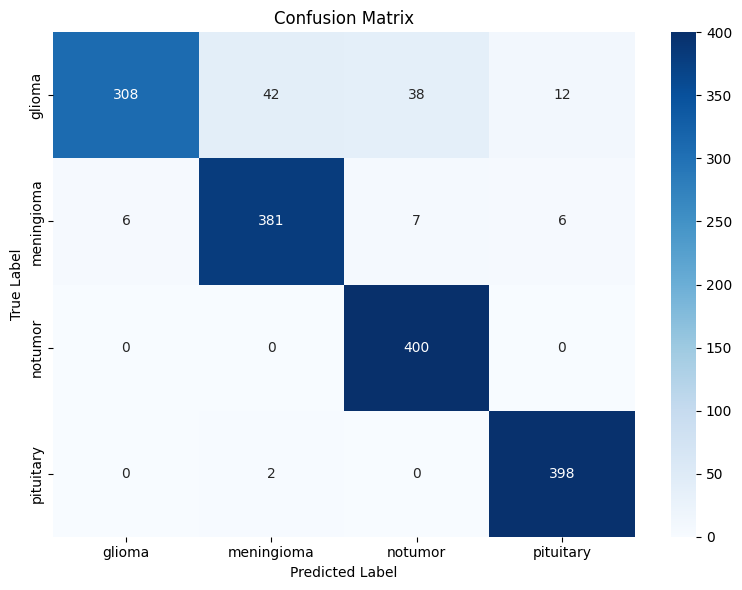

In [ ]:
model.load_state_dict(
torch.load(
    '/content/drive/MyDrive/spikingjelly/best_model_Resformer_ti_brain_tumour.pth',
    weights_only=True,
    map_location=device
)
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=16,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2,
    drop_last=True
)

model.eval()
criterion = nn.CrossEntropyLoss()

correct, total = 0, 0
total_loss = 0

all_preds = []
all_labels = []

print("\nRunning evaluation...")
with torch.no_grad():
    pbar = tqdm(testloader)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)

        outputs = model(imgs)

        if outputs.dim() == 3:
            outputs = outputs.mean(0)

        loss = criterion(outputs, labels)

        preds = outputs.argmax(1)

        total_loss += loss.item()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        functional.reset_net(model)

        pbar.set_postfix(acc=correct / total)

acc = correct / total
avg_loss = total_loss / len(testloader)

f1_macro = f1_score(all_labels, all_preds, average='macro')
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("\n===== RESULTS =====")
print(f"Accuracy       : {acc:.4f}")
print(f"Loss           : {avg_loss:.4f}")
print(f"F1 (macro)     : {f1_macro:.4f}")
print(f"F1 (weighted)  : {f1_weighted:.4f}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=testset.classes))
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=testset.classes,
    yticklabels=testset.classes
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()